**Мы подошли к той части, где модель перестаёт быть красивой архитектурной схемой и начинает становиться чем-то живым.**

До этого момента мы собирали конструкцию по частям. У нас уже есть токен-эмбеддинги, позиционная информация, multi-head attention, FFN, Transformer block, финальная нормализация и выходной слой, который переводит скрытые представления в logits по словарю. Проще говоря: модель уже умеет взять последовательность токенов и выдать для каждой позиции набор чисел - сырые оценки вероятности следующего токена. В прошлой главе это и было последней точкой: архитектура почти собрана, logits уже получаются, и именно они дальше должны попасть в loss-функцию.



**Архитектура сама по себе не учится.**
Даже идеально собранная модель - это ещё не интеллект. Если её веса случайны, то перед нами просто сложная функция со случайным поведением. Она может честно прогонять данные через attention, FFN и выходной слой, но ответы будут такими же случайными, как значения её параметров.

Именно training loop делает из архитектуры обучаемую систему.

Это сердце обучения. Не отдельная формула. Не один вызов loss.backward(). И даже не optimizer сам по себе. А **повторяющийся цикл**, внутри которого модель много раз:

1. получает вход,

2. делает предсказание,

3. получает численную оценку своей ошибки,

4. вычисляет, какие параметры в эту ошибку внесли вклад,

5. немного меняет веса,

6. и снова пробует.

Шаг за шагом. Батч за батчем. Эпоха за эпохой.

В этой главе нам важно не просто выучить три слова - loss, backpropagation, optimizer. Важно увидеть, как они работают вместе. Потому что отдельно каждый из них ещё не объясняет обучение. Только вместе они превращают набор матриц в модель, которая постепенно начинает угадывать структуру языка.

**Давайте сначала посмотрим на весь процесс сверху, без формул.**

Представьте, что у нас есть очень маленькая языковая модель. Ей дают кусок текста:

`Кот любил`

и хотят, чтобы она предсказала следующий токен:

`сметану`

Модель берёт входные токены, прогоняет их через всю свою архитектуру и на выходе выдаёт logits - числа по всему словарю. Например, она может сказать:

* кот → 1.2

* сметану → 0.4

* молоко → 2.1

* спал → -0.3

Это ещё не вероятности. Просто сырые оценки.

Потом мы сравниваем её ответ с правильным. Правильный токен - `сметану`, а модель сильнее всего поверила в `молоко`. Значит, она ошиблась. Эту ошибку надо превратить в число. Этим занимается **loss function**.

Но мало узнать, что модель ошиблась. Надо понять:

- **какие именно веса привели к этой ошибке;**

- **в какую сторону их менять;**

- **насколько сильно их менять.**

Здесь в работу вступают две другие части:

- **backpropagation** вычисляет градиенты, то есть чувствительность ошибки к каждому параметру;

- **optimizer** использует эти градиенты и обновляет веса.

После этого модель делает следующий шаг обучения. Потом ещё один. И ещё. Один шаг редко что-то меняет радикально. Но тысячи и миллионы шагов постепенно сдвигают параметры туда, где предсказания становятся лучше.

Вот это и есть **training loop** в самом простом виде:

**вход → предсказание → ошибка → градиенты → обновление весов → повторение**

Архитектура отвечает на вопрос:

`как именно модель считает?`

Training loop отвечает на другой вопрос:

`как именно модель становится лучше?`

Transformer block умеет смешивать контекст через attention и перерабатывать признаки через FFN. Output layer умеет переводить скрытые представления в logits по словарю. Но ни attention, ни FFN, ни lm_head сами по себе не знают, какие веса хорошие, а какие плохие.

Модель не рождается с пониманием языка. Она приходит в мир с случайными параметрами и учится только потому, что training loop снова и снова сталкивает её предсказания с правильными ответами.

Кажется, что главное уже позади: attention разобрали, transformer block собрали, logits получили - почти всё. На самом деле до этого момента мы в основном строили тело модели. А **training loop** - это уже механизм, который запускает **обучение**.

**Loss** - это **численная мера того, насколько плохо модель справилась на текущем примере или батче.**

Это очень важная формулировка.

* Loss не говорит модели, как исправиться.
* Loss не меняет веса.
* Loss не является обучением сам по себе.

Loss делает другое: он превращает качество предсказания в число, с которым дальше уже можно работать математически.


В модели, это устроено как **next-token prediction**.

То есть модель на каждой позиции пытается предсказать следующий токен. Причём делает это не для одного места, а сразу для всех позиций последовательности.



Например, есть текст:

`Кот любил сметану`

Тогда вход и цель удобно сдвинуть на один шаг:

вход: `Кот любил`

target: `любил сметану`

или для более длинного фрагмента:

`input_ids = [Кот, любил, сметану]`

`target_ids = [любил, сметану, <eos>]`

Благодаря каузальной маске, которую мы уже вводили в главе про attention, токен на каждой позиции не видит будущее и может опираться только на прошлое и текущее. Это и делает задачу честной: модель действительно учится предсказывать следующий токен, а не подглядывать в ответ.

### От logits к вероятностям

На выходе модели мы получаем **logits**:

$$z = [z_1, z_2, \ldots, z_V]$$
где $V$ - размер словаря.

Эти числа сами по себе неудобно интерпретировать как вероятности. Поэтому концептуально мы применяем **softmax**:

$$p_i = \frac{e^{z_i}}{\sum_{j=1}^V e^{z_j}}$$

* $z_i$ - логит токена $i$
* $p_i$ - итоговая вероятность токена $i$

Смысл такой: чем выше logit нужного токена относительно остальных, тем выше его вероятность.

Для языковых моделей стандартный выбор - **cross-entropy loss**.

Для одного правильного токена она выглядит так:

$$L = - \log p_y$$

* $L$ - loss
* $y$ - индекс правильного токена
* $p_y$ - вероятность, которую модель дала правильному токену

Если модель дала правильному токену высокую вероятность, например $p_y = 0.9$, то $L = -\log(0.9)$, это очень маленькое число, если $p_y = 0.05$, то $L= - \log (0.05)$, и это уже очень большое число

То есть cross-entropy делает ровно то, что нам нужно:

* награждает высокую вероятность правильного токена;

* сильно штрафует низкую вероятность правильного токена.

Рассмотрим простой пример:

Пусть модель для четырёх токенов словаря выдала logits:

$$[2.0, 1.0, 0.1, -1.0]$$

После softmax получаем вероятности примерно:

$$[0.638, 0.235, 0.095, 0.032]$$

Теперь рассмотрим два случая.

**Случай 1.** Правильный токен - первый.

Тогда: $$L=-\log (0.638) \approx 0.449$$

Loss небольшой. Модель сработала неплохо.

Тогда: $$L=-\log (0.235) \approx 1.449$$

Loss уже заметно больше. Потому что правильный ответ не был главным кандидатом.

Именно это нам и нужно. **Loss должен не просто говорить «ошибка есть», а отражать степень уверенности модели в правильном ответе.**

В LLM мы считаем loss не по одному токену, а сразу по множеству позиций батча.

Если всего в батче $N$ предсказаний, то удобно думать так:
$$L = -\frac{1}{N}\sum_{t=1}^N \log p_{t, y_t}$$

* $t$ пробегает все позиции всех примеров в батче,
* $y_t$ - правильный токен для позиции $t$
* $p_{t, y_t}$ - вероятность, которую модель дала правильному токену в этой позиции.

**То есть общий loss - это средняя ошибка по всем предсказаниям текущего шага.**

### Главная идея backpropagation

После forward pass мы знаем одно число - **loss**.

Но одного числа мало. Нужно понять:

*Какие параметры внесли вклад в эту ошибку?
Если слегка изменить конкретный вес, loss уменьшится или увеличится?
И насколько сильно?*

Ответ на эти вопросы дают **градиенты**.

Градиент параметра - это производная loss по этому параметру:
$$\frac{\partial L}{\partial W}$$

**Backpropagation - это алгоритм, который систематически вычисляет градиенты всех параметров модели, начиная от loss и двигаясь назад по цепочке вычислений.**

**Именно назад**. Поэтому и «back-propagation» - распространение назад.

Чтобы это не казалось магией, полезно представить модель как **вычислительный граф**.

Каждая операция - это узел:

- линейный слой,
- сложение,
- softmax,
- нормализация,
- матричное умножение,
- ReLU,
- и так далее.

Во время forward pass PyTorch строит цепочку зависимостей: кто из чего был получен. После этого, когда мы вызываем `loss.backward()`, фреймворк идёт по этой цепочке назад и применяет правила дифференцирования.

В основе backpropagation лежит цепное правило.

Пусть есть простая цепочка:

$$x \rightarrow h \rightarrow L$$

* h = f(x, W)
* L = g(h)

Тогда производная $L$ по весу $W$ считается так:
$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial h} \cdot \frac{\partial h}{\partial W}$$

Смысл очень простой.

Чтобы узнать, как вес влияет на loss, мы раскладываем вопрос на два шага:

1. как промежуточное значение $h$ влияет на loss
2. как сам вес $W$ влияет на $h$

А потом связываем их.

В реальной модели таких промежуточных величин очень много. Но идея остаётся той же. Backpropagation просто повторяет эту логику по всей цепочке вычислений.

**Важно**, cначала обязательно нужен forward pass, а только потом back-propagation. Почему?

Потому что без него мы не знаем:

- какие конкретно значения получились внутри модели,

- каков итоговый loss на текущем батче,

- через какие промежуточные состояния прошёл сигнал.

**Градиенты зависят не от абстрактной архитектуры вообще, а от конкретного прогона на конкретных данных.** Сначала модель должна ошибиться на текущем батче. Только после этого есть смысл вычислять, как именно эта ошибка зависит от параметров.

Именно поэтому порядок всегда такой:

1. forward,

2. loss,

3. backward.


### Что происходит в LLM во время backpropagation

Здесь уже можно связать идею с нашей архитектурой.

Модель выдала logits по словарю.
Cross-entropy сравнила их с правильными следующими токенами.
Получился loss.

**Теперь backpropagation переносит этот сигнал назад:**

* через lm_head,

* через финальную нормализацию,

* через все Transformer blocks,

* внутри блока - через FFN,

* через residual-пути,

* через attention,

* через матрицы $W_Q, W_K, W_V, W_O$

* через эмбеддинги токенов и позиций.

То есть ошибка от плохого предсказания следующего токена реально добирается до всех обучаемых матриц, которые участвовали в вычислении.

**После backward() у нас есть градиенты. Но параметры всё ещё не изменились.**

Если градиент показывает направление роста ошибки, то, чтобы уменьшить ошибку, **нужно идти в противоположную сторону.**

Отсюда рождается формула градиентного спуска:

$$W \leftarrow W - \eta \frac{\partial L}{\partial W}$$

* $W$ - параметр
* $\eta$ - шаг обучения
* $\frac{\partial L}{\partial W}$ - градиент


Смысл этой записи:

* берём текущий вес,
* смотрим, как loss зависит от него,
* делаем маленький шаг в сторону уменьшения ошибки.

Если шаг слишком большой, обучение начинает вести себя нервно:

- перескакивает через хорошие области,
- loss может колебаться,
- иногда вообще расходится.

Если шаг слишком маленький, модель учится мучительно медленно:

- loss падает очень слабо,
- обучение может застревать,
- кажется, будто всё «не работает», хотя просто шаг слишком осторожный.

Самый простой optimizer - это обычный **SGD**: градиент есть, шаг сделали, пошли дальше.

Но в реальных нейросетях градиенты шумные, масштабы у параметров разные, и простой SGD не всегда ведёт себя удобно, особенно для первых экспериментов.

Поэтому для нашей первой модели логично использовать **Adam**.

Adam тоже опирается на градиенты, но делает это умнее:

- ведёт усреднение направления градиента,
- учитывает масштаб прошлых градиентов,
- помогает шагам быть более стабильными.

Если записать формально, Adam считает две скользящие статистики:

$$m_t = \beta_1 m_{t-1}+(1-\beta_1)g_t$$
$$v_t = \beta_2 v_{t-1}+(1-\beta_2)g_t^2$$

* $g_t$ - текущий градиент 
* $m_t$ - среднее направление
* $v_t$ - средний масштаб квадратов градиентов

А затем обновляет параметр примерно так:
$$W_t = W_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

Интуитивно это значит:

- если по параметру градиенты стабильно указывают в одну сторону, Adam это учитывает;
- если по параметру градиенты слишком шумные или слишком большие, Adam уменьшает резкость шага;
- шаг получается более адаптивным.

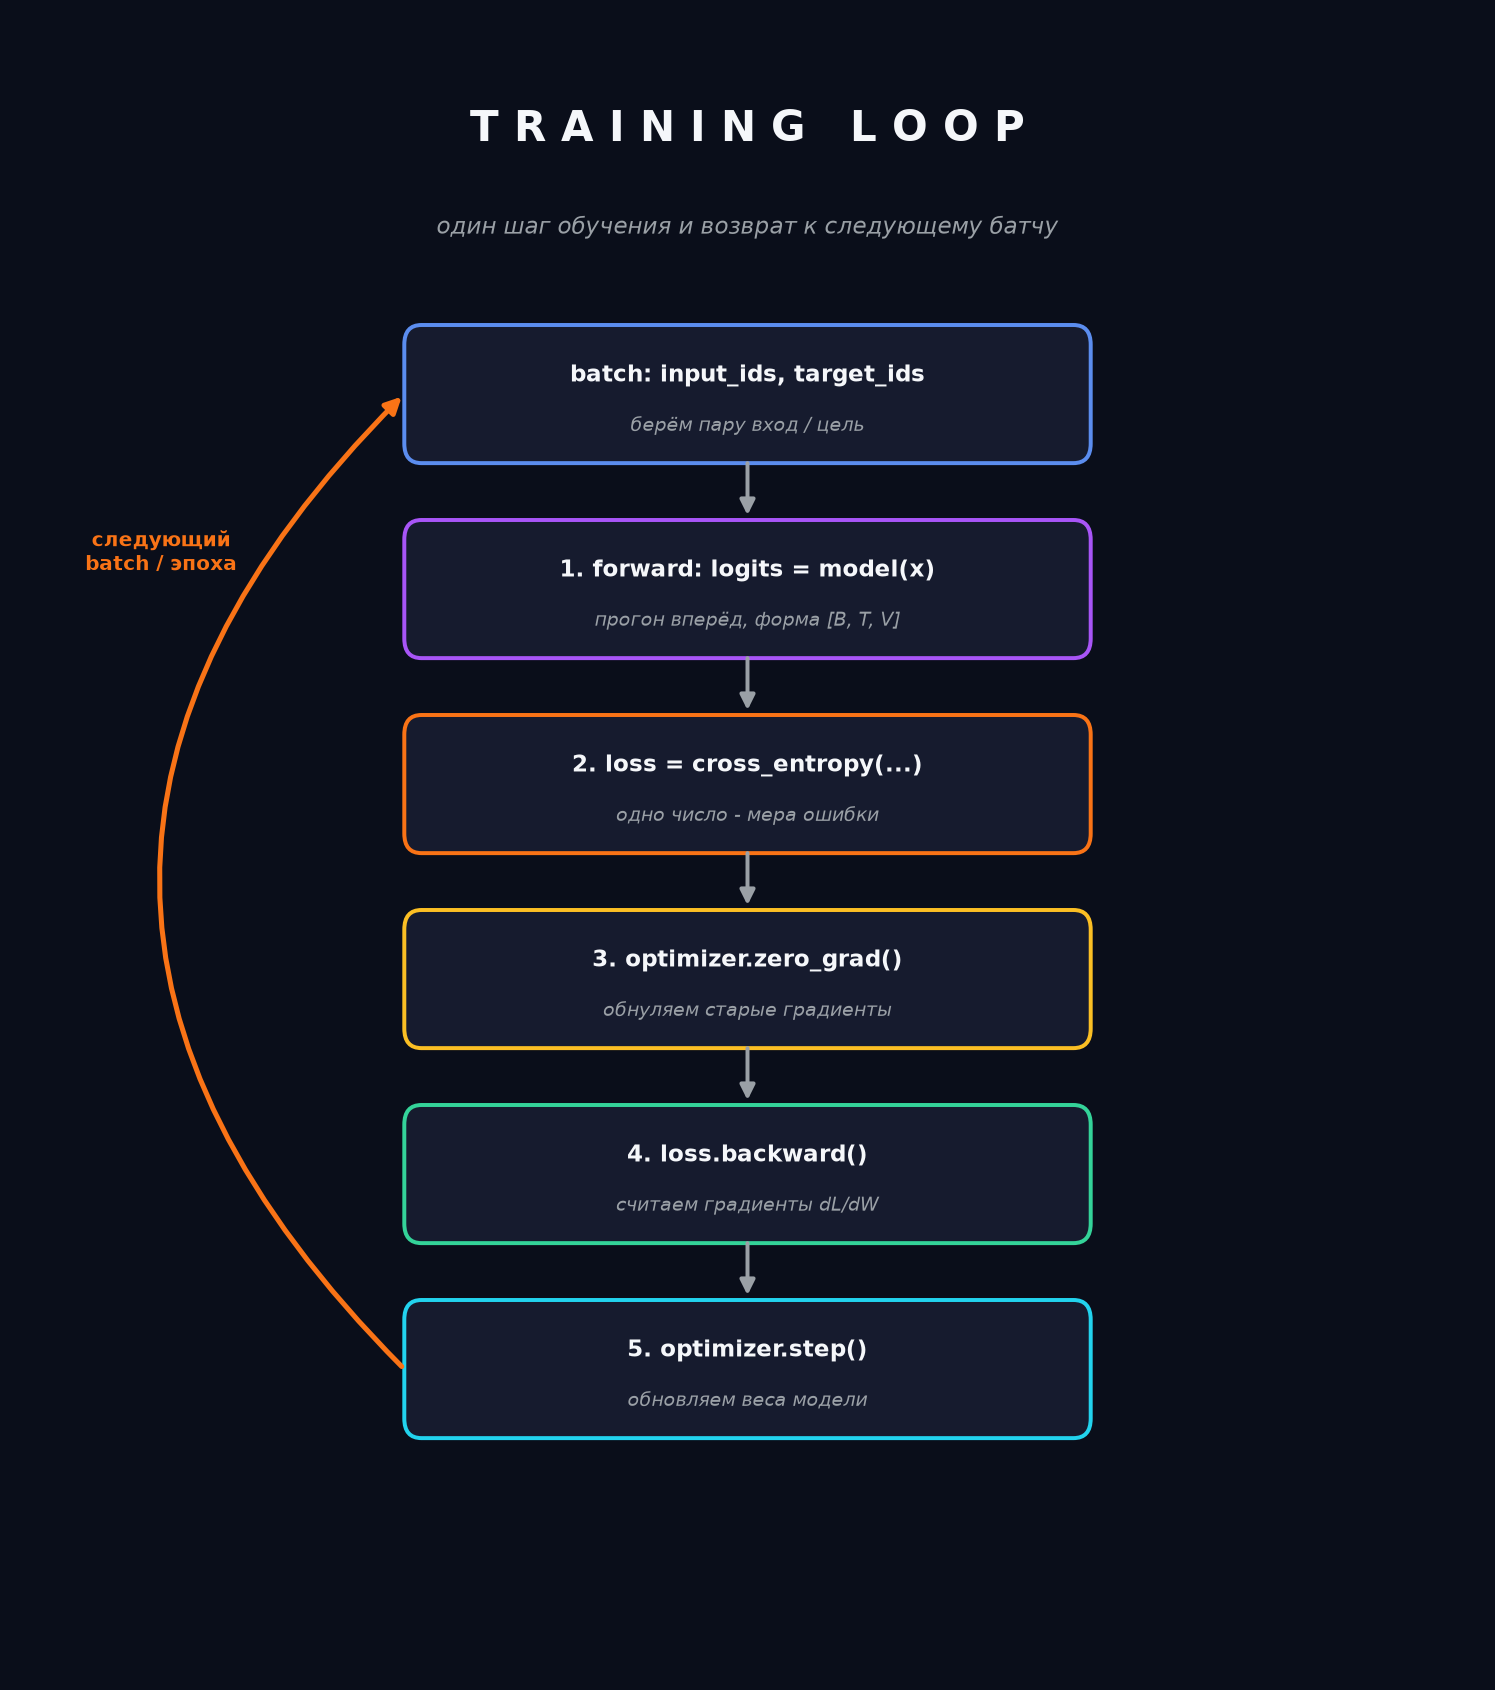

И теперь реализуем всё это!

Добавим количество эпох обучения в config.py. Новая строка одна:

`    num_epochs: int = 50              # Количество эпох обучения`

Создаём новый файл в нашем проекте - `train.py`. Это и есть тот самый training loop, о котором мы говорили всю главу, только теперь в виде рабочего кода:

Давайте перейдём в файл `dataset.py`:

Проблема в том, что когда `end_idx + 1` выходит за пределы длины `self.input_ids`, срез `targets` становится короче, чем `chunk`. Например, если `self.input_ids` имеет длину `10`, `max_length = 4`, и мы берём последний элемент (`idx = 6`), то:

* `chunk = self.input_ids[6:10] → длина 4`
* `targets = self.input_ids[7:11] → длина 3 (потому что 11 > 10)`

Это также исправим!

И после этого - можно запустить обучение!.

**С каждой эпохой loss всё меньше и меньше, а это значит, что модель всё лучше угадывает следующий токен!**

Важно понимать: **Увеличение эпох - это не всегда хорошо**

Когда хорошо: если модель ещё учится.

Признаки:

* loss стабильно падает;
* модель ещё явно не «поняла» текст.

Когда плохо: **если модель начинает переобучаться (overfitting).**

Это значит: модель запоминает данные, а не учится обобщать.

Что такое переобучение (очень важно понять):

Представьте, вы дали модели текст:

`кот сидит на диване
собака бежит домой
кот любит молоко`

Если обучать долго, модель может начать запоминать строки буквально.

И вместо:

`кот → "сидит", "любит"`

она будет выдавать:

`кот сидит на диване (копия)`

Или представьте себе студента, который:

- 1-10 эпох - учится понимать тему;
- 10-30 эпох - закрепляет знания;
- 30-100 эпох - начинает зубрить ответы.


**Ну и хороший маркер, что эпохи увеличивать нет смысла, - если loss перестал меняться.**

